<a href="https://colab.research.google.com/github/vvrgit/ReinforcementLearningCourse/blob/main/GridWorldProblem_DeterministicEnv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

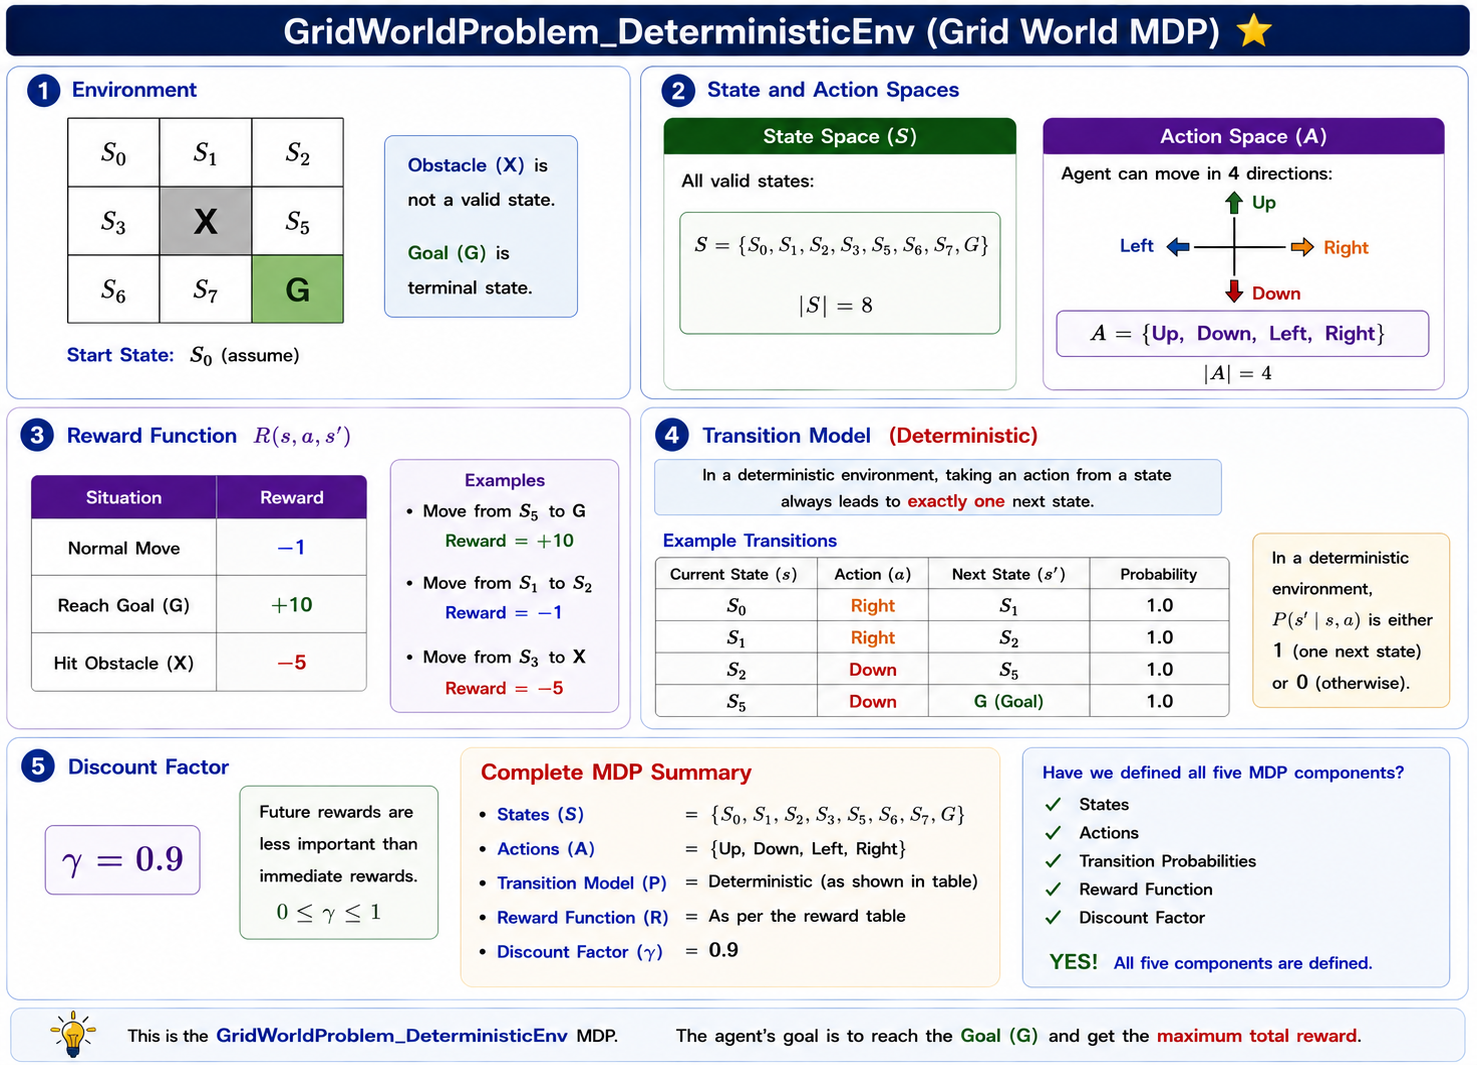

# **Define State Space**

In [ ]:
states=["S0","S1","S2","S3","S5","S6","S7","G"]
print(states)

['S0', 'S1', 'S2', 'S3', 'S5', 'S6', 'S7', 'G']


# **Action Space**

In [ ]:
actions=["up","down","left","right"]
print(actions)

['up', 'down', 'left', 'right']


# **Reward**

In [20]:
reward={
    "move":-0.5,
    "goal":100,
    "obs":-2
}
print(reward)

{'move': -0.5, 'goal': 100, 'obs': -2}


In [1]:
gama=0.9 #discuount_factor
print(f"Discount Factor={gama}")

Discount Factor=0.9


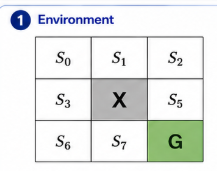

In [ ]:
transition={
    ("S0","right"):"S1",
    ("S0","down"):"S3",
    ("S0","left"):"S0",
    ("S0","up"):"S0",
    ("S1","right"):"S2",
    ("S1","down"):"S1",
    ("S1","left"):"S0",
    ("S1","up"):"S1",
    ("S2","right"):"S2",
    ("S2","down"):"S5",
    ("S2","left"):"S1",
    ("S2","up"):"S2",
    ("S3","right"):"S3",
    ("S3","down"):"S6",
    ("S3","left"):"S3",
    ("S3","up"):"S0",
    ("S5","right"):"S5",
    ("S5","down"):"G",
    ("S5","left"):"S5",
    ("S5","up"):"S2",
    ("S6","right"):"S7",
    ("S6","down"):"S6",
    ("S6","left"):"S6",
    ("S6","up"):"S3",
    ("S7","right"):"G",
    ("S7","down"):"S7",
    ("S7","left"):"S6",
    ("S7","up"):"S7",
}

# **Environment**

In [24]:
%%writefile grid_env.py
def env_state():
  states=["S0","S1","S2","S3","S5","S6","S7","G"]
  return states

def env_actions():
  actions=["up","down","left","right"]
  return actions

def env_reward():
  reward={
    "move":-0.5,
    "goal":100,
    "obs":-2
  }
  return reward

def env_df():
  gama=0.9
  return gama

def env_transition():
  transition={
    ("S0","right"):"S1",
    ("S0","down"):"S3",
    ("S0","left"):"S0",
    ("S0","up"):"S0",
    ("S1","right"):"S2",
    ("S1","down"):"S1",
    ("S1","left"):"S0",
    ("S1","up"):"S1",
    ("S2","right"):"S2",
    ("S2","down"):"S5",
    ("S2","left"):"S1",
    ("S2","up"):"S2",
    ("S3","right"):"S3",
    ("S3","down"):"S6",
    ("S3","left"):"S3",
    ("S3","up"):"S0",
    ("S5","right"):"S5",
    ("S5","down"):"G",
    ("S5","left"):"S5",
    ("S5","up"):"S2",
    ("S6","right"):"S7",
    ("S6","down"):"S6",
    ("S6","left"):"S6",
    ("S6","up"):"S3",
    ("S7","right"):"G",
    ("S7","down"):"S7",
    ("S7","left"):"S6",
    ("S7","up"):"S7"
  }
  return transition

Overwriting grid_env.py


# **Random Agent**

In [25]:
import grid_env as env
import random

state=env.env_state()
print(state)
actions=env.env_actions()
print(actions)
reward=env.env_reward()
print(reward)
gama=env.env_df()
print(gama)
transition=env.env_transition()
print(transition)

current_state="S0"
total_reward=0

while current_state!="G":
  action=random.choice(actions)
  next_state=transition[(current_state,action)]

  if(next_state==current_state):
    total_reward=total_reward+reward["obs"]
  elif(next_state=="G"):
    total_reward=total_reward+reward["goal"]
  else:
    total_reward=total_reward+reward["move"]

  print(f"current state: {current_state} \t action: {action} \t next state: {next_state} \t total_reward={total_reward}")
  current_state=next_state

print(f"total reward: {total_reward}")

['S0', 'S1', 'S2', 'S3', 'S5', 'S6', 'S7', 'G']
['up', 'down', 'left', 'right']
{'move': -1, 'goal': 100, 'obs': -10}
0.9
{('S0', 'right'): 'S1', ('S0', 'down'): 'S3', ('S0', 'left'): 'S0', ('S0', 'up'): 'S0', ('S1', 'right'): 'S2', ('S1', 'down'): 'S1', ('S1', 'left'): 'S0', ('S1', 'up'): 'S1', ('S2', 'right'): 'S2', ('S2', 'down'): 'S5', ('S2', 'left'): 'S1', ('S2', 'up'): 'S2', ('S3', 'right'): 'S3', ('S3', 'down'): 'S6', ('S3', 'left'): 'S3', ('S3', 'up'): 'S0', ('S5', 'right'): 'S5', ('S5', 'down'): 'G', ('S5', 'left'): 'S5', ('S5', 'up'): 'S2', ('S6', 'right'): 'S7', ('S6', 'down'): 'S6', ('S6', 'left'): 'S6', ('S6', 'up'): 'S3', ('S7', 'right'): 'G', ('S7', 'down'): 'S7', ('S7', 'left'): 'S6', ('S7', 'up'): 'S7'}
current state: S0 	 action: left 	 next state: S0 	 total_reward=-10
current state: S0 	 action: down 	 next state: S3 	 total_reward=-11
current state: S3 	 action: right 	 next state: S3 	 total_reward=-21
current state: S3 	 action: up 	 next state: S0 	 total_reward